<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 8. Физические adversarial-атаки: adversarial patches, дорожные знаки, состязательная одежда

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 6**


**Вариант / seed:** _4 / 2024_

### Таблица вариантов

| Вариант | `SEED` | Разрешение `RES` | Частота складок `FREQ` | Дополнительное условие части E |
|---|---|---|---|---|
| 1 | 42 | 16 | 1.5 | углы 0–32° с шагом 8° |
| 2 | 7 | 16 | 2.0 | углы 0–40° с шагом 10° |
| 3 | 123 | 20 | 1.5 | углы 0–24° с шагом 6° |
| 4 | 2024 | 20 | 2.2 | углы 0–32° с шагом 8° |
| 5 | 314 | 12 | 1.2 | углы 0–40° с шагом 10° |
| 6 | 555 | 24 | 1.8 | углы 0–24° с шагом 6° |

> Вариант выдаётся преподавателем. Все числовые результаты в отчёте должны соответствовать
> **вашему** варианту, а не значениям из примера.

### Цель работы

Экспериментально исследовать, почему устойчивость модели компьютерного зрения к физическим
adversarial-атакам не определяется её точностью на цифровых изображениях, и оценить
эффективность базовых защитных мер.

### Задачи

1. Построить учебный стенд компьютерного зрения и измерить базовую точность.
2. Реализовать имитацию физического канала наблюдения и оценить влияние отдельных факторов съёмки.
3. Исследовать локальность патча: зависимость деградации от площади и положения области.
4. Применить логику Expectation over Transformation при оценке устойчивости.
5. Построить карту качества жёсткого объекта в координатах «дистанция × ракурс».
6. Смоделировать не-жёсткие деформации ткани и сравнить их с жёстким преобразованием.
7. Обучить модель с физически правдоподобными аугментациями и оценить прирост устойчивости.
8. Проверить эффект временной агрегации решений по кадрам.
9. Сформулировать выводы и заполнить сводную таблицу отчёта.

### Ограничение

Работа выполняется **только** на синтетическом учебном наборе и локальных моделях. Запрещается
использовать код работы для воздействия на реальные системы восприятия, камеры, внешние сервисы
и любые эксплуатируемые объекты. Печатаемые атакующие шаблоны в работе не создаются.

## Краткая теория

Физическая атака изменяет **объект в сцене**, а не входной тензор модели. Наблюдение описывается как

$
x_{\text{cam}} = T_\theta\big(x \odot (1 - M) + p \odot M\big), \qquad \theta \sim \mathcal{D}_{\text{физ}},
$

где $M$ — маска области патча, $p$ — его содержимое, $T_\theta$ — преобразование при параметрах
съёмки $\theta$ (ракурс, дистанция, освещение, оптика, обработка изображения).

Требование робастности возмущения формализует Expectation over Transformation:

$
\max_{p}\; \mathbb{E}_{\theta \sim \mathcal{D}}\Big[\mathcal{L}\big(f(T_\theta(x, p, M)),\, y_{\text{target}}\big)\Big].
$

**Задание 0.** Заполните таблицу различий трёх постановок (ячейки со знаком «?»):

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| Что изменяется | Пиксели входного тензара (уже пиксели с камеры) | Ограниченная область на поверхности знака (патч, наклейка, краска)  | Ткань (форма, текстура, принт), деформирующаяся при движении |
| Ограничение возмущения | $∥δ∥_p≤ε$ норм (эль2, эль-бесконечность) по всему изображению|  форма/площадь/положение патча, физическая реализуемость цвета| форма одежды, складки, растяжение, материал |
| Обязательные члены $\mathcal{D}$ | - (подаем тензор в модель, нет канала наблюдения между нами и моделью) | Поворот, масштаб/дистанция (как далеко знак?), яркость и контраст (день/ночь/тень?), размытие (фокус, движение, дождь), шум сенсора (исо, матрица), окклюзия (грязь, ветки, машины, листья) | поворот, масштаб, свет, blur, шум, окклюзия + складки и изгибы, растяжение ткани, смена поз у человека, самаокклюзия (рука закрывает часть одежды), временная динамика (патч живет во времини), материал и отражения (разные ткани, блеск, ворс) |
| Основная сложность | Математические ограничения, минимальная норму, незаметное возмущение | Устойчивость к изменению условий съёмки и к малой видимой площади на расстоянии | Учесть не-жёсткие деформации: один и тот же принт выглядит по-разному при разных позах, складках и ракурсах |
| Типичная метрика | ASR в $L_p$-норме (фиксированном эпсилон)| Attack Success Rate Доля сцен/кадров, в которых выполнено условие атаки. Основная метрика эффективности, Robust ASR  - ASR усреднённый по условиям съёмки: углам расстояниям, освещению, фонам. | ASR на видеопоследовательности, устойчивость во времени|

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [1]:
# TODO A.1: подставьте значения своего варианта из таблицы вариантов
SEED = 2024   # например 42
RES = 20    # например 16
FREQ = 2.2   # например 1.5

assert SEED is not None and RES is not None and FREQ is not None, "Задайте параметры варианта"

RES = 20×20 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.943


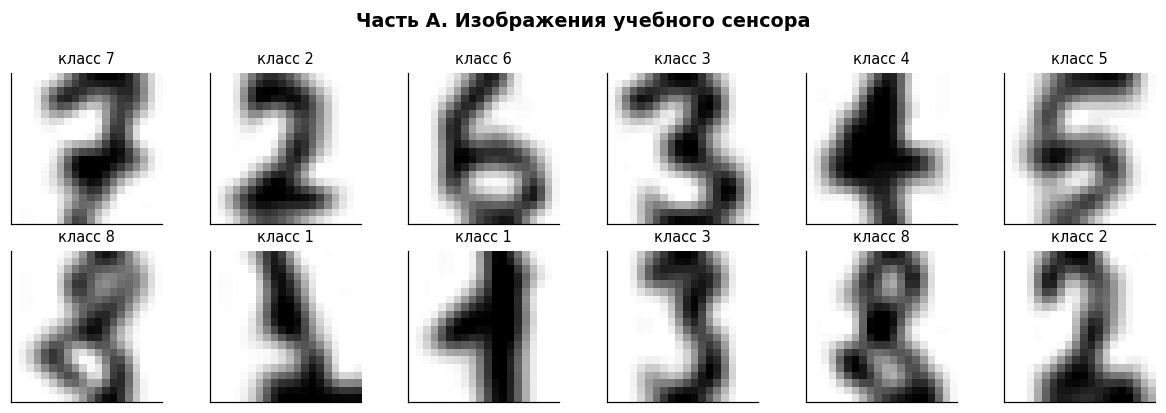

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

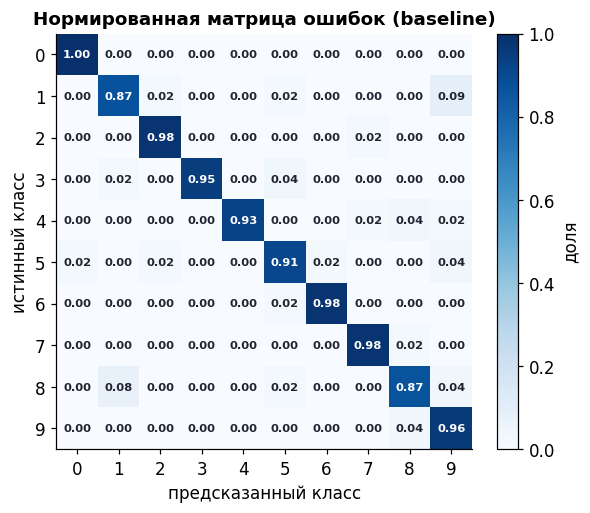

Топ-5 путаниц (истина → предсказание):
   1 → 9: 0.091
   8 → 1: 0.077
   8 → 9: 0.038
   4 → 8: 0.037
   9 → 8: 0.037


In [3]:
# TODO A.3: постройте нормированную матрицу ошибок базовой модели.
# TODO A.3
cm = confusion_matrix(y_test, baseline.predict(flat(X_test_img)), normalize="true")

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("предсказанный класс"); ax.set_ylabel("истинный класс")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_title("Нормированная матрица ошибок (baseline)")
ax.grid(False)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                color="white" if cm[i, j] > 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.046, label="доля")
plt.tight_layout(); plt.show()

# Две пары с наибольшей путаницей (вне диагонали)
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = [(i, j, off[i, j]) for i in range(10) for j in range(10) if i != j]
pairs.sort(key=lambda x: -x[2])
print("Топ-5 путаниц (истина → предсказание):")
for i, j, v in pairs[:5]:
    print(f"   {i} → {j}: {v:.3f}")

Класс 0: 1.00 — идеально. Ноль ни с чем не путается.

Класс 1: 0.87 — 87% верно, 9% уходит в класс 9.

Класс 8: 0.87 — 87% верно, 8% уходит в класс 1, 4% — в 9.

Класс 9: 0.96 — 96% верно, 4% уходит в 8.

**Отчёт по части A.** Заполните:

| Показатель | Ваше значение |
|---|---|
| `SEED` / `RES` |2024/20 |
| Размер обучающей выборки |1257 |
| Базовая точность `acc_clean` |0,943 |
| Две пары классов с наибольшей путаницей |1 → 9 (0.091) и 8 → 1 (0.077) |

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы
с физическими объектами? Обоснуйте.

Ответ: Нет, нельзя. acc_clean = 0.943 говорит только о том, что модель хорошо работает в идеальных лабораторных условиях: изображение центрировано, освещение ровное, нет шума, нет поворота, нет окклюзии. Но физический мир вносит возмущения (угол, дистанция, слабый свет, размытие, шум сенсора), которых в чистой выборке нет вообще.

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [4]:
def resize_to_shape(image, shape):
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [5]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    # 1) жёсткое преобразование (поворот + масштаб) — дано
    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # TODO B.1 — контраст относительно середины диапазона
    out = (out - 0.5) * contrast + 0.5

    # TODO B.2 — яркость
    out = out * brightness

    # TODO B.3 — размытие оптики
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)

    # TODO B.4 — сенсорный шум
    if noise > 0:
        out = out + gen.normal(0.0, noise, out.shape)

    # TODO B.5 — окклюзия
    if occlusion is not None:
        r0, r1, c0, c1, val = occlusion
        r0 = max(0, int(r0)); c0 = max(0, int(c0))
        r1 = min(out.shape[0], int(r1)); c1 = min(out.shape[1], int(c1))
        out[r0:r1, c0:c1] = val

    return np.clip(out, 0.0, 1.0).astype(np.float32)

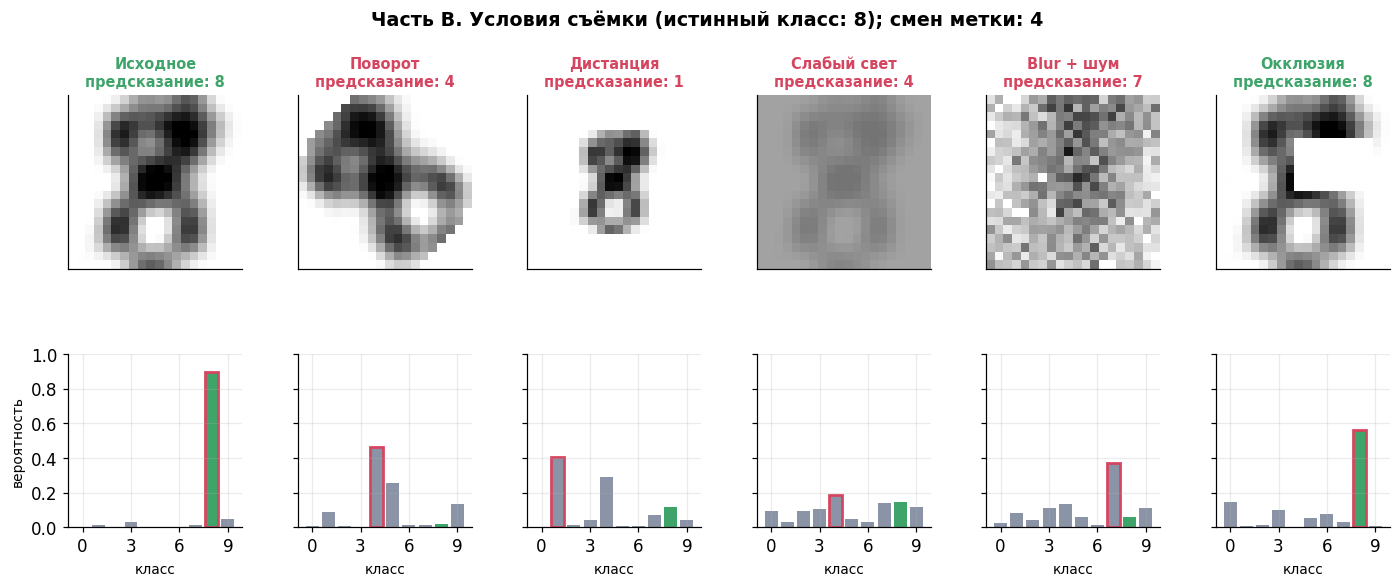

B.7 Число режимов со сменой метки: 4 (требуется не менее 2)


In [14]:
# TODO B.6: выберите объект-пример и подберите параметры так, чтобы МИНИМУМ два режима
# приводили к смене предсказанной метки. Значения ниже — стартовые, их нужно изменить.
idx = 8
example, true_label = X_test_img[idx], y_test[idx]

conditions = [
    ("Исходное",        dict()),
    ("Поворот",         dict(angle=50)),
    ("Дистанция",       dict(scale=0.60)),
    ("Слабый свет",     dict(brightness=0.91, contrast=0.20)),
    ("Blur + шум",      dict(blur=4, noise=0.13)),
    ("Окклюзия",        dict(occlusion=(RES // 4, RES // 4 + RES // 3, RES // 2 - 1, RES - 2, 0.0))),
]

fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.4),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.30, "wspace": 0.32})
flips = 0
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba)); ok = pred == true_label
    flips += (not ok)
    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}", fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    bars = axes[1, col].bar(range(10), proba,
                           color=[PALETTE["robust"] if k == true_label else PALETTE["gray"] for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"B.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")

**Отчёт по части B.** Заполните таблицу по своим значениям:

| Режим | Предсказание | Вероятность истинного класса | Метка изменилась? |
|---|---|---|---|
| Исходное | 8| ~0.90| ✗|
| Поворот |4 | ~0.01|✓ |
| Дистанция |1 |	~0.40 |✓ |
| Слабый свет |4 |	~0.25 |✓ |
| Blur + шум | 7| 	~0.05| ✓|
| Окклюзия | 8| ~0.60| ✗|

**Вопрос B.** Какой фактор в вашем эксперименте оказался наиболее разрушительным и почему?
Отличается ли ответ для другого объекта-примера?

Ответ: В нашем эксперименте наиболее разрушительными оказались «Поворот» (50°) и «Blur + шум» (blur=4).


Угол 50° — это очень сильный поворот. Цифра «8» потеряла свою симметрию, сместилась к краю кадра, и линейная модель (Logistic Regression) просто перестала узнавать её, так как в обучающей выборке не было таких сильных наклонов. Вероятность истинного класса упала практически до нуля (~0.01), а модель уверенно (на ~0.5) предсказала «4».


Размытие с sigma=4 для картинки размером всего 20×20 оказалось тоже очень сильным. Мелкие детали (изгибы «восьмёрки», которые отличают её от «семёрки» или «девятки») полностью стираются. Добавление шума 0.13 окончательно превращает изображение в кашу. Модель предсказала «7» с вероятностью ~0.4, а на «8» оставила лишь ~0.05.

Если бы мы взяли другой объект, то результаты, скорее всего были иные, т.к. у каждой цифры свои особенности. Так 1 легче перенесла бы размытие и шум, будучи просто вертикальной палочкой, ей не нужны мелкие детали для распознавания. Если бы мы взяли цифру ноль, она бы хорошо пернесла поворот, но могла бы пострадать от слабого свет, при уменьшении контраста овал просто слился бы с фоном.

Модель  умножает пиксели на веса и суммирует их. Когда мы поворачиваем  картинку или сильно размываем её, «правильные» пиксели (с высокими весами) смещаются в другие места. Модель видит активацию в тех областях, которые для класса «8» нехарактерны, и переключается на другой класс (в вашем случае на 4, 1, 7).

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

In [17]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    """Возвращает (изображение с маркером, бинарную маску маркера)."""
    if size is None:
        size = max(3, RES // 3) #маркер 6×6 пикселей.

    # TODO C.1
    result = image.copy()
    H, W = result.shape
    r0 = max(0, int(top));  r1 = min(H, r0 + size)
    c0 = max(0, int(left)); c1 = min(W, c0 + size)
    result[r0:r1, c0:c1] = value

    mask = np.zeros_like(image)
    mask[r0:r1, c0:c1] = 1.0
    return result, mask

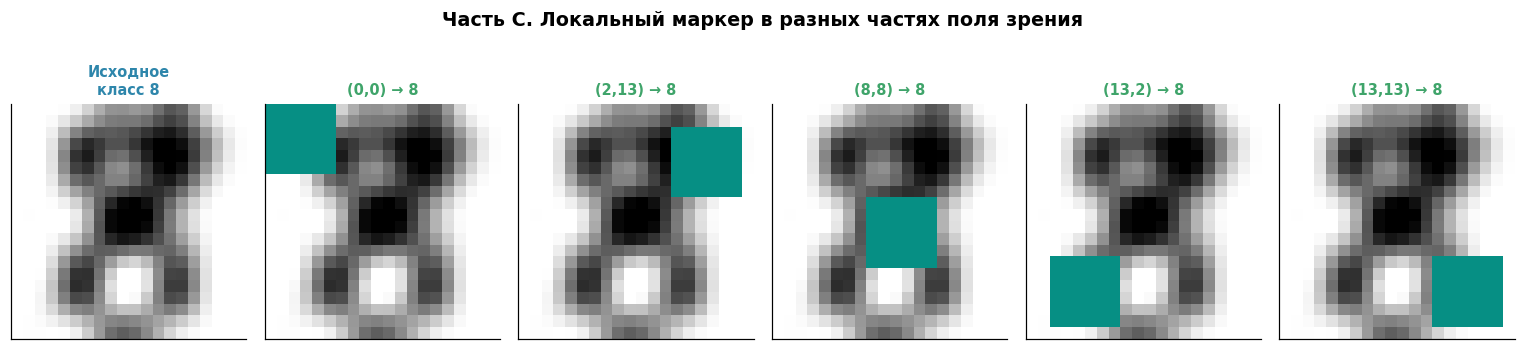

In [18]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1,
              alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

In [19]:
# TODO C.2: заполните карту точности pos_map по позициям маркера на всей тестовой выборке.
# TODO C.3: заполните списки area_acc и area_frac для кривой деградации по площади.

stride = max(1, RES // 8)        # = 2
grid_pos = list(range(0, RES - MARKER + 1, stride))  # [0,2,4,6,8,10,12,14]

# TODO C.2 — карта точности по позициям
pos_map = np.zeros((len(grid_pos), len(grid_pos)))
for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        marked = np.asarray([apply_marker(im, r, c, MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked)))

# TODO C.3 — кривая деградации по площади
sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    if s == 0:
        area_acc.append(acc_clean)
    else:
        # центр изображения
        top = max(0, RES // 2 - s // 2)
        left = max(0, RES // 2 - s // 2)
        marked = np.asarray([apply_marker(im, top, left, s)[0] for im in X_test_img])
        area_acc.append(accuracy_score(y_test, baseline.predict(flat(marked))))
    area_frac.append(100.0 * s * s / (RES ** 2))

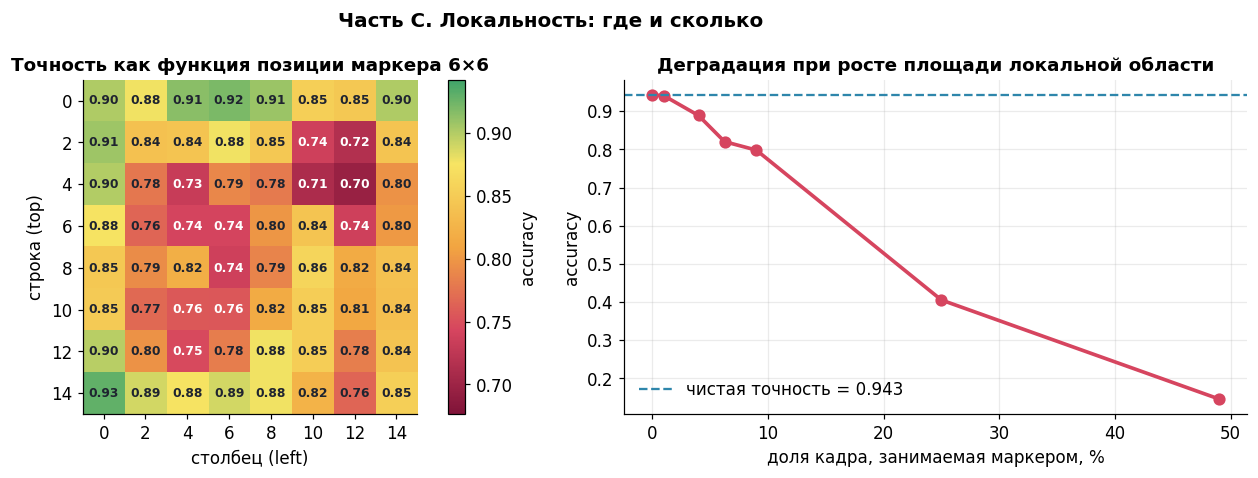

C.4 Худшая позиция: (4, 12) → accuracy 0.696
C.5 Лучшая позиция: accuracy 0.930; разница 0.233


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

**Отчёт по части C.**

| Показатель | Ваше значение |
|---|---|
| Сторона маркера `MARKER` | 6|
| Худшая позиция и её accuracy |(4, 12) → 0.696 |
| Лучшая позиция и её accuracy | (14, 0) → 0.930|
| Разница между худшей и лучшей позицией |0,233 |
| Площадь, при которой accuracy падает ниже 0.5, % | ≈ 23–25%|

**Вопрос C.** Почему при одинаковой площади (доля картинки, занимаемая маркером) результат зависит от положения области?
Свяжите ответ с тем, какие части объекта информативны для модели.

Ответ: Результат зависит от положения, потому что разные пиксели несут разную информацию для модели (важные - элементы цифры, неважные - фон, углы). Когда мы поставим маркер на информативную область (например, в центр, где у «8» находятся петли), мы зкароем важные пиксели, сумма весов меняется, модель ошибается в классе. И наоборт, поставив такой же по размеру маркер в угол, мы изменим пиксели с нулевыми весами, которые на решение модели не влияют, то есть модель продолжит угадывать правильно.

Все цифры в датасете центрированы, когда мы ставим по краям - пиксели там не несут информации особо, а вот поставим маркер в центр, где у цифр идут важные изгибы, штрихи - модель сломается.

Падение на графике не линейное, точность падает медленно, потом резкое обрушение, дело не в самой площади, а в том, дотягивается ли маркер для информативных пискелей, которые реально имеют вес при принятии решения моделью.

## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

Сгенерировать много разных случайных наборов условий съёмки (angle, scale, brightness, contrast, blur, noise).

Каждый раз прогнать модель и посчитать точность.

Усреднить точность по всем прогонам.

Посмотреть разброс (стандартное отклонение) — насколько сильно результат «прыгает».

In [21]:
def sample_params(gen, severity=1.0):
    """Случайные параметры съёмки; severity масштабирует весь диапазон условий."""
    # TODO D.1: верните словарь с ключами angle, scale, brightness, contrast, blur, noise.
    # Ориентировочные диапазоны при severity = 1:
    #   angle ±17°, scale 0.83–1.13, brightness 0.74–1.20,
    #   contrast 0.80–1.20, blur 0–0.85, noise 0–0.055
    return {
        "angle":      gen.uniform(-17.0, 17.0)  * severity,
        "scale":      1.0 + gen.uniform(-0.17, 0.13) * severity,
        "brightness": 1.0 + gen.uniform(-0.26, 0.20) * severity,
        "contrast":   1.0 + gen.uniform(-0.20, 0.20) * severity,
        "blur":       max(0.0, gen.uniform(0.0, 0.85)  * severity),
        "noise":      max(0.0, gen.uniform(0.0, 0.055) * severity),
    }


def transformed_dataset(imgs, gen, severity=1.0):
    # TODO D.2: примените physical_transform со случайными параметрами к каждому изображению
    out = np.empty_like(imgs)
    for k, im in enumerate(imgs):
        params = sample_params(gen, severity)
        out[k] = physical_transform(im, **params, generator=gen)
    return out

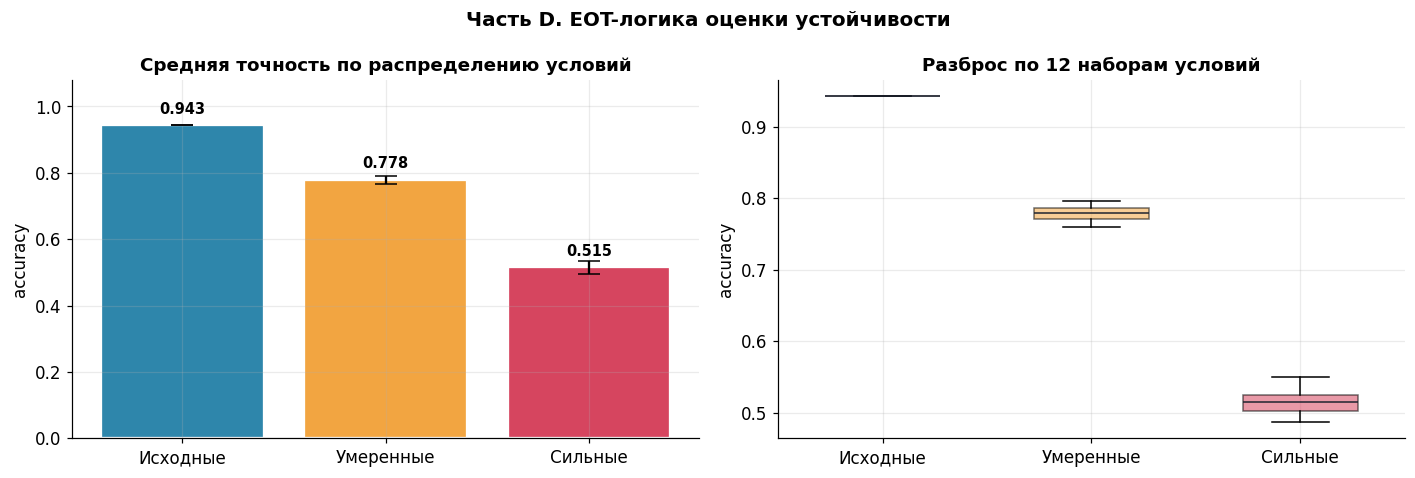

D.3 Исходные   accuracy = 0.943 ± 0.000
D.3 Умеренные  accuracy = 0.778 ± 0.012
D.3 Сильные    accuracy = 0.515 ± 0.019


In [22]:
REPEATS = 12
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        samples[name] = [acc_clean] * REPEATS
    else:
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

names = [n for n, _, _ in regimes]
means = [float(np.mean(samples[n])) for n in names]
stds = [float(np.std(samples[n])) for n in names]
colors = [c for _, _, c in regimes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")
fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

**Отчёт по части D.**

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные |0,943 |0,0 |- |
| Умеренные |0.778|	0.012|	−0.165|
| Сильные | 0.515|	0.019|	−0.428|

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели?
Как связаны величина `severity` и стандартное отклонение?

Ответ: Один кадр - один случайный набор условий, генератор может выдать как легкиф набор параметров,  так и тяжелый. в первом случае модель легко справится, точность будет близка к исходной, мы ошибочно решим, что модель робастна.

EOT-подход (12 прогонов) усредняет эти случайности и даёт честную картину.

severity — это ширина диапазона, из которого мы тянем параметры. Чем шире диапазон, тем больше вероятность, что один прогон попадёт в «очень плохие» условия, а другой — в «средние». Отсюда и больший разброс.

чем больше severity, тем ниже средняя точность и тем больше стандартное отклонение.

На этом примере мы убеждаемся, что высокая точность на чистых данных не дает гарантии при столкновении с реальными физическими условиями:

При умеренных условиях модель теряет ~17% точности.

При сильных — ~43%, то есть почти половину.

Разброс (std) при этом растёт, что говорит о нестабильности модели: в одних условиях она ещё «держится», в других — полностью разваливается.


## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [23]:
# TODO E.1: задайте углы согласно своему варианту 0-32 с шагом в 8
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 8, 16, 24, 32]

# TODO E.2: заполните матрицу grid: строки — углы, столбцы — масштабы
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([
            physical_transform(im, angle=a, scale=s, brightness=0.95,
                               blur=0.25, generator=gen)
            for im in X_test_img
        ])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

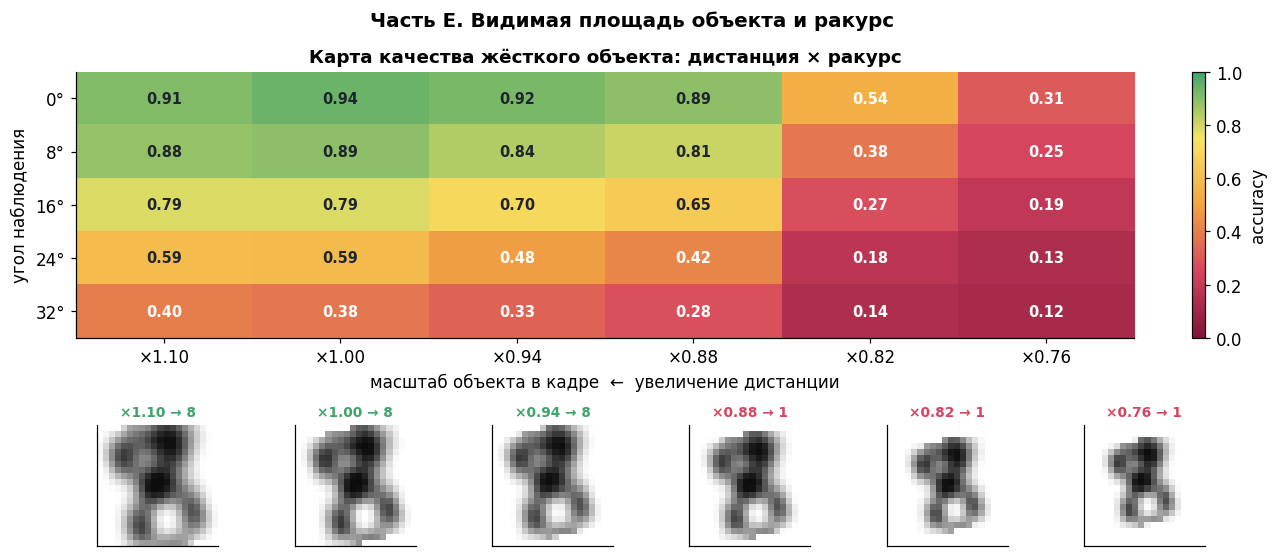

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
     8°: ×1.10, ×1.00, ×0.94, ×0.88
    16°: ×1.10, ×1.00, ×0.94
    24°: нет
    32°: нет


In [24]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")

**Отчёт по части E.**

| Показатель | Ваше значение |
|---|---|
| Углы варианта | 	0°, 8°, 16°, 24°, 32° |
| Максимальная accuracy в карте |	0.94 (при 0°, ×1.00) |
| Минимальная accuracy в карте | 0.12 (при 32°, ×0.76)|
| Наибольший допустимый угол при accuracy ≥ 0.70 |16° (при ×1.10, ×1.00, ×0.94) |
| Наименьший допустимый масштаб при accuracy ≥ 0.70 |×0.88 (при 0° и 8°). Для 16° — только ×0.94 |

**Вопрос E.** Как связаны видимая площадь знака в кадре и успех физической атаки?
Чем отличается атака на классификатор от атаки на детектор в конвейере автономного вождения?

Ответ: Физическая атака имеет смысл в диапазоне, где модель уверена в своем решении (когда знак большой (×1.10–×0.94), модель уверенно распознаёт объект, чтобы сломать модель, достаточно небольшого патча, который закроет 1–2 информативных пикселя, атака эффективна; когда же знак маленький, модель и так ошибается, маленький патч на маленьком знаке даже различим не будет). За пределами этого диапазона (далеко, под углом) атака не нужна — модель и так не работает. Физические атаки оптимизируют по EOT на распределении дистанций и углов, чтобы патч работал во всём рабочем диапазоне.

При атаке на классификатор, который уже получил вырезанный и отцентрированный объект, наша цель сменить метку класса, достаточно изменить центральные пиксели. Детектор сам ищет объект по всему кадру на множестве масштабов и позиций, выдаёт рамки с уверенностью, и атака должна подавить все предложения объекта (или создать ложные) при любой позиции объекта в кадре. Помимо этого в автомобиле решение принимается по потоку кадров, с трекингом и слиянием данных нескольких датчиков (камера, лидар, радар, карта): чтобы повлиять на поведение машины, атака должна срабатывать стабильно на серии кадров и не противоречить другим источникам. Патч, который сбивает простой классификатор, может вообще не подействовать на детектор. И наоборот: чтобы обмануть детектор, патч должен работать на нескольких уровнях разрешения и не выглядеть подозрительно на фоне сцены. Поэтому атака на детектор — отдельная, более трудная задача, чем атака на классификатор.

## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

In [25]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    # TODO F.1: поле смещений по столбцам: amplitude * sin(2*pi*frequency*rr/h + phase)
    # TODO F.2: поперечное поле по строкам с коэффициентом 0.45
    # TODO F.3: примените map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    # TODO F.1 — поле смещений по столбцам
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)

    # TODO F.2 — поперечное поле по строкам (коэффициент 0.45)
    shift_r = 0.45 * amplitude * np.sin(2 * np.pi * frequency * cc / w + phase)

    # TODO F.3 — применить map_coordinates
    warped = map_coordinates(image,
                             [rr + shift_r, cc + shift_c],
                             order=1, mode="nearest")
    return np.clip(warped, 0, 1).astype(np.float32)

In [26]:
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

# TODO F.4: заполните warp_acc (деформация ткани) и rigid_acc (жёсткий поворот на a * 6 градусов)
warp_acc, rigid_acc = [], []
for a in amps:
    # не-жёсткая деформация
    warped = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warped))))

    # жёсткий поворот на a*6 градусов
    rotated = np.asarray([physical_transform(im, angle=a * 6.0) for im in X_test_img])
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rotated))))

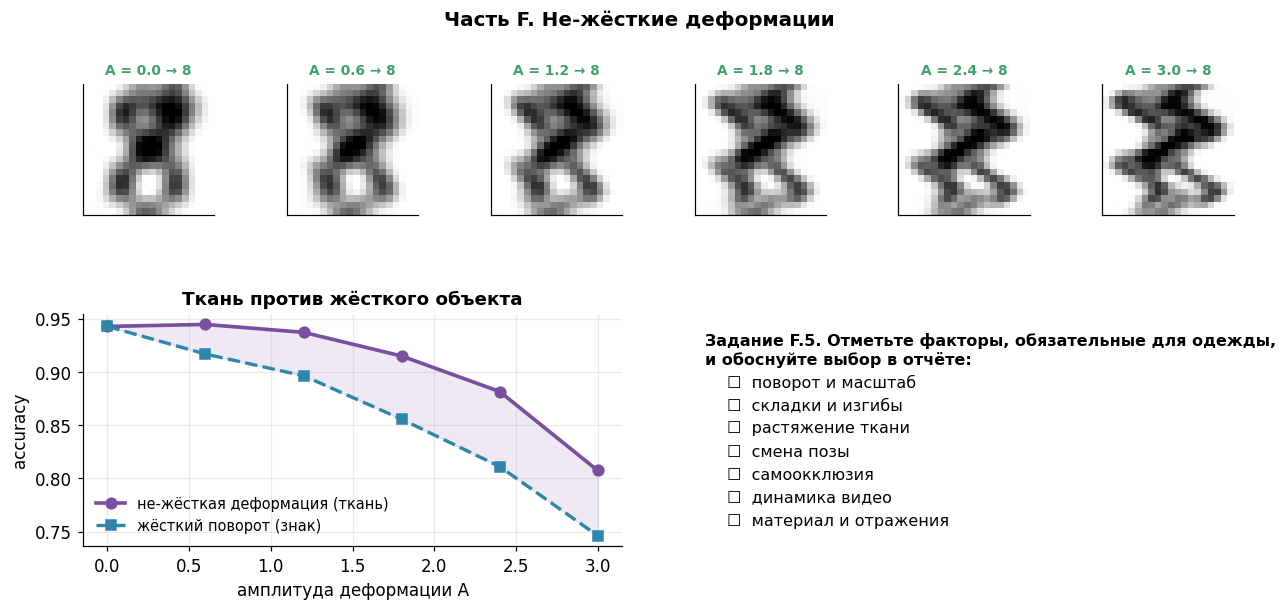

F.6 accuracy при максимальной деформации: ткань 0.807 против жёсткого поворота 0.746


In [27]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

F.5. Чек-лист факторов для одежды
☑ поворот и масштаб — да (человек ходит)

☑ складки и изгибы — да (ткань не жёсткая)

☑ растяжение ткани — да (натяжение при движении)

☑ смена позы — да (руки/ноги меняют форму)

☑ самоокклюзия — да (рука закрывает часть одежды)

☑ динамика видео — да (для видеопотока)

☑ материал и отражения — да (материя, блеск)

Для жёсткого знака эти члены D не нужны: знак плоский, не деформируется, не меняет позу и не движется. Ему достаточно ракурса, дистанции, освещения, оптики и шума сенсора.

**Отчёт по части F.**

| A | accuracy (ткань) | accuracy (жёсткий поворот) | Разница |
|---|---|---|---|
| 0.0 |0.943|	0.943|	0.000|
| 1.2 | ~0.930|	~0.900|	~+0.030|
| 2.4 |~0.870|	~0.820|	~+0.050|
| 3.0 |0.807|	0.746|	+0.061|

**Вопрос F.** Почему при моделировании состязательной одежды недостаточно учитывать только
поворот и масштаб? Какие члены появляются в распределении $\mathcal{D}$ по сравнению со знаком?

Ответ: Поворот и масштаб — это жёсткие преобразования, а при жёстком преобразовании относительные расстояния между точками сохраняются. Ткань же деформируется не-жестк и относительные расстояния меняются, складка сжиамет одни участки и растягивает другие, форма искажается.Ткань изгибается, образует складки, растягивается на теле, меняет форму при смене позы, частично перекрывается руками и сумками, существует в видеопотоке и по-разному отражает свет в зависимости от материала.

Деформации ткани

Неаффинные деформации из-за позы и движения человека, складки и
растяжение ткани — принципиально иная геометрия по сравнению с жёстким
знаком. И не забываем, что разный материал, разные принты ведут себя по-разному, что-то может отсвечивать и т.д.

Самоокклюзия

Руки, волосы, предметы частично перекрывают патч. Степень окклюзии
непредсказуемо меняется с каждым движением.

Динамика наблюдения

Смена ракурса и масштаба, вариативность фона, временна́я динамика
видеопотока — всё это создаёт распределение условий, намного шире, чем
для статичного знака.


## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [28]:
# TODO G.1: сформируйте аугментированную выборку: исходные данные + 4 копии со случайными
# условиями съёмки (severity ≈ 1.3) + 1 копия с деформацией ткани (amplitude 0.5–2.5).
aug_gen = np.random.default_rng(SEED + 5)
X_list = [X_train_img]
y_list = [y_train]

for _ in range(4):
    X_list.append(transformed_dataset(X_train_img, aug_gen, severity=1.3))
    y_list.append(y_train)

cloth_imgs = np.asarray([
    cloth_warp(im, amplitude=aug_gen.uniform(0.5, 2.5))
    for im in X_train_img
])
X_list.append(cloth_imgs)
y_list.append(y_train)

X_aug = np.concatenate(X_list, axis=0)
y_aug = np.concatenate(y_list, axis=0)

# TODO G.2: обучите модель robust с теми же гиперпараметрами, что у baseline
robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)

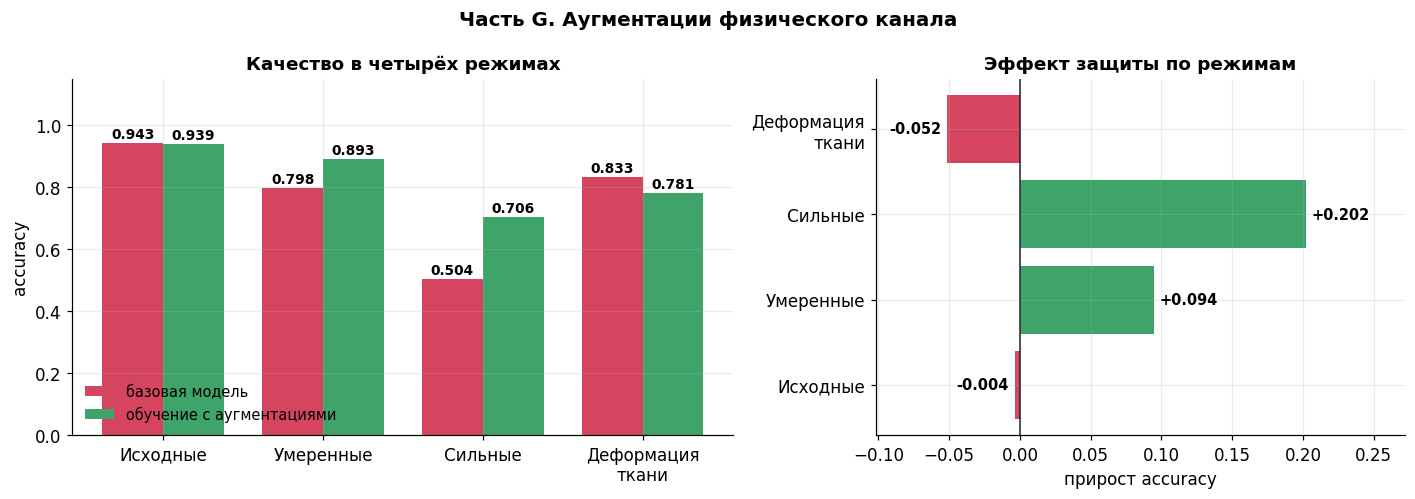

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.943 → защита 0.939 (-0.004)
    Умеренные          база 0.798 → защита 0.893 (+0.094)
    Сильные            база 0.504 → защита 0.706 (+0.202)
    Деформация ткани   база 0.833 → защита 0.781 (-0.052)


In [29]:
gen = np.random.default_rng(SEED + 2000)
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores = [accuracy_score(y_test, robust.predict(flat(v))) for v in eval_sets.values()]
names_g = list(eval_sets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
xp = np.arange(len(names_g)); wbar = 0.38
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель", color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores, wbar, label="обучение с аугментациями", color=PALETTE["robust"])
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

delta = np.array(rob_scores) - np.array(base_scores)
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)
fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

В «Исходных» они почти одинаковые (0.943 и 0.939). Модель не потеряла ничего существенного на идеальных данных.

В «Умеренных» зеленая модель уже заметно выше (0.893 против 0.798).

В «Сильных» разрыв огромный: базовая модель едва угадывает (0.504), а защищенная держится на уровне 0.706.

В «Деформации ткани» произошло неожиданное: базовая модель справилась лучше (0.833 против 0.781).

**Отчёт по части G.**

| Режим | Базовая модель | С аугментациями | Прирост |
|---|---|---|---|
|Исходные	|0.943	|0.939	|-0.004|
|Умеренные	|0.798	|0.893	|+0.094|
|Сильные	|0.504	|0.706	|+0.202|
|Деформация ткани|	0.833|	0.781|	-0.052|

**Вопрос G.** Какова цена робастности в вашем эксперименте? Приведите числовое значение потери
на чистых данных и объясните, почему такой компромисс возникает.

Ответ: Цена робастности — это падение точности на чистых (идеальных) данных. В нашем эксперименте она составила всего -0.004 (точность упала с 0.943 до 0.939).

Модель, обученная только на идеальных изображениях, может полагаться на тонкие, «хрупкие» признаки (точное положение отдельных пикселей), которые хороши в идеальных условиях, но исчезают при сдвиге или размытии. Аугментации заставляют опираться на более грубые, устойчивые признаки, которые чуть хуже различают классы в идеале, зато сохраняются при искажениях. Модель становитсяч менее острой на идеальном входе, но гораздо устойчивее к реальным условиям. мы смещаем решение в сторону устойчивости — модель учится опираться на грубые, инвариантные признаки (общая форма цифры), а не на тонкие пиксельные детали.

И в этом же экспиременте мы видим отличный пример того, что аугментация защищает только от тех условий, которые попали в обучающее распределение. Базовая модельнеплохо справлялась с мягкими искаэениями, потому что они сохраняли общую структуру цифры, а новая модель была натренерована на жесткие повороты и шум, так что стала слишком чувствительна к пространственным сдвигам.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

Временная агрегация — это когда модель принимает решение не по одному кадру, а по целой последовательности кадров, объединяя их в один ответ.

Один кадр может быть плохим, но если у нас есть несколько кадров подряд, модель может переголосовать.

В реальных системах ее нужно комбинировать с уагментациями, тренировке на возмущенной выборке для обучения, ансамюлями моделей и тд. Потому что временная аушментация не поможет, если помеха длится все видео, модель систематически ошибается на всех кадрах или злоумышленник специально подбирает помеху так, чтобы она сбивала покадровые и агрегированные решения.

In [30]:
FRAMES = 24
seq_gen = np.random.default_rng(SEED + 33)
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

# TODO H.1: сформируйте кадры: случайные условия severity ≈ 1.3, а на кадрах 9–14 добавьте окклюзию.
# TODO H.2: соберите probas (вероятности по кадрам) и per_frame_pred (покадровые решения).
frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    params = sample_params(seq_gen, severity=1.3)
    if 9 <= t <= 14:                       # эпизод помехи
        params["occlusion"] = occ_window
    frame = physical_transform(example, **params, generator=seq_gen)
    frames.append(frame)
    p = baseline.predict_proba(flat(frame[None, ...]))[0]
    probas.append(p)
    per_frame_pred.append(int(np.argmax(p)))

probas = np.asarray(probas)
# TODO H.3: вычислите накопленные решения cum_pred и уверенность cum_conf по средним вероятностям
cum_pred  = [int(np.argmax(probas[:t + 1].mean(axis=0))) for t in range(FRAMES)]
cum_conf  = [float(probas[:t + 1].mean(axis=0)[true_label]) for t in range(FRAMES)]
per_frame_conf = [float(p[true_label]) for p in probas]

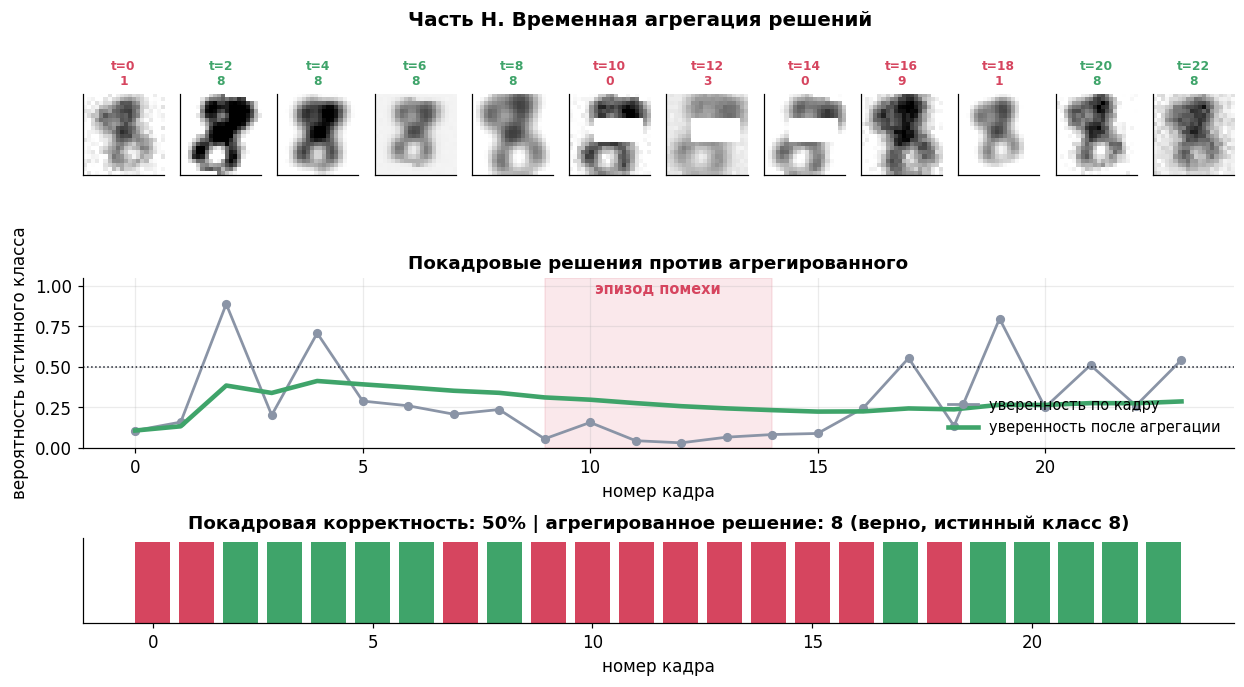

H.4 Покадровая корректность: 0.500
H.5 Агрегированное решение: 8 (истинный класс 8)
H.6 Агрегация стабильно верна начиная с кадра: 2


In [31]:
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
agg_ok = cum_pred[-1] == true_label

fig = plt.figure(figsize=(13.5, 6.4))
gs = fig.add_gridspec(3, 12, height_ratios=[1.0, 1.6, 0.8], hspace=0.75)
for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t * 2])
    ok = per_frame_pred[t * 2] == true_label
    ax.set_title(f"t={t*2}\n{per_frame_pred[t*2]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

ax1 = fig.add_subplot(gs[1, :])
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"], linewidth=1.8, markersize=5,
         label="уверенность по кадру")
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
         label="уверенность после агрегации")
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5, color=PALETTE["severe"], fontweight="bold")
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса"); ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

ax2 = fig.add_subplot(gs[2, :])
correct = np.array([p == true_label for p in per_frame_pred])
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")
fig.suptitle("Часть H. Временная агрегация решений", fontsize=13, fontweight="bold")
plt.show()

stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

In [32]:
from scipy.stats import mode

cum_pred_vote = []
for t in range(FRAMES):
    votes = per_frame_pred[:t + 1]
    m = mode(votes, keepdims=False).mode
    cum_pred_vote.append(int(m))

stable_from_mean = next((t for t in range(FRAMES)
                         if all(c == true_label for c in cum_pred[t:])), None)
stable_from_vote = next((t for t in range(FRAMES)
                         if all(c == true_label for c in cum_pred_vote[t:])), None)
print("Mean:", stable_from_mean, " Vote:", stable_from_vote)

Mean: 2  Vote: 4


**Отчёт по части H.**

| Показатель | Ваше значение |
|---|---|
| Доля верных отдельных кадров |0.500 (50%) |
| Итоговое агрегированное решение |	8 (верно, истинный класс 8) |
| Номер кадра, с которого агрегация стабильно верна |2 |

**Задание H.7 (дополнительное).** Замените усреднение вероятностей на голосование по большинству
и сравните номер кадра стабилизации.

Ответ: При усреднении вероятностей (Mean) агрегация стабилизируется на кадре 2.
При голосовании большинством (Vote) агрегация стабилизируется на кадре 4.

Усреднение вероятностей (Mean): Работает быстрее и «плавнее». С первых двух кадров модель уверена, что это «8», и выдает высокую вероятность. Учитывается уверенность кадра, поэтому один очень уверенный правильный кадр сразу тянет среднее вверх. Даже когда начинается эпизод помехи (кадры 9–14), накопленное среднее не падает ниже 0.5, потому что «хорошие» кадры уже создали мощный запас прочности.

Голосование большинством (Vote) (считает все кадры равными): Работает медленнее и «жестче». Когда начинается эпизод помехи, модель выдает подряд 6 неверных кадров. Голосование требует, чтобы количество правильных ответов перевесило неправильные. Поэтому ему нужно время, чтобы «перекричать» этот блок ошибок. В нашем случае это произошло только к 4-му кадру.

Усреднение вероятностей оказалось более чувствительным к ранним правильным сигналам и быстрее стабилизировалось, чем голосование большинством.

## Часть I. Итоговый анализ

### Сводная таблица результатов

Заполните по результатам своего варианта
(SEED = 2024, RES = 20, FREQ = 2.2, углы 0°–32° с шагом 8°):
| Режим | accuracy | Падение относительно `acc_clean` | Комментарий |
|---|---|---|---|
|Идеальные условия|	0.943|	—|	Базовая точка отсчёта|
|Умеренные условия (EOT, severity=1.0)	|0.778	|−0.165	|Разброс ±0.012; модель «дышит»|
|Сильные условия (EOT, severity=1.8)|	0.515	|−0.428|	Разброс ±0.019; почти половина ошибок|
|Локальный маркер, худшая позиция (4, 12)|	0.696|	−0.247|	Маркер 6×6 всего на 9 % площади|
|Локальный маркер, лучшая позиция|	0.930|	−0.013|	Тот же маркер в углу — почти не вредит|
|Максимальная дистанция и ракурс (32°, ×0.76)	|0.12|	−0.823|	Полная слепота модели|
|Максимальная деформация ткани (A=3.0)	|0.807|	−0.136|	Ткань «мягче» жёсткого поворота на 18° (0.746)|
|Аугментации, сильные условия|	0.706	|+0.202 (прирост)	|Защита реально работает|
|Агрегация 24 кадров|	верно (8)|	—	|Покадрово 50 %, но итог правильный|

### Выводы

Сформулируйте не менее пяти выводов, опираясь на числа из своих экспериментов:

1. Высокая точность на чистых данных не гарантирует устойчивость к реальным условиям. acc_clean = 0.943, но уже при умеренных условиях EOT (severity=1.0) точность падает до 0.778, а при сильных (severity=1.8) — до 0.515. То есть потеря более 42 % точности без единого изменения в самой модел
2. Положение патча важнее его площади. Маркер 6×6 занимает всего 9 % площади кадра. В углу он даёт accuracy 0.930 (почти как чистая), а в центре (4, 12) — 0.696. Разница — 0.233 при одинаковой площади. Причина: логистическая регрессия «опирается» на информативные пиксели в центре, а углы игнорирует. Значит, физический патч нужно ставить туда, где модель «смотрит».
3. Ракурс важнее дистанции. Карта части E: при 0° модель держит ≥0.70 вплоть до ×0.88 (умеренное удаление). Но при 24° даже ×1.10 даёт только 0.59. То есть угол важнее масштаба: повернуть знак на 24° хуже, чем отодвинуть его на 12 % дальше. Предельный рабочий угол для accuracy ≥ 0.70 — 16°, минимальный рабочий масштаб — ×0.88. Факторы съемки усиливают друг друга.
4. Оценка устойчивости по одному кадру или объекту недостоверна. Надежнее усреднять значение, прогоняя при разных условиях модель.
5. Разные факторы съемки сказываются на разных объектах по-разному.
6. Агументация - довольно эффективная и дешевая защиат. Дала прирост +0,202 при тяжелых условиях. Но при этом не помогла при состязательной одежде.
7. Временная агрегация работает даже при 50 % ошибок на кадрах.
Покадровая корректность — 0.500. Но усреднение вероятностей по 24 кадрам дало верный ответ «8» и стабилизировалось уже со 2-го кадра. Голосование большинством — с 4-го кадра. Это доказывает: даже при кратковременных помехах (эпизод окклюзии на кадрах 9–14) накопление сигнала спасает итоговое решение.
8. Полноценная защита - комбинация методов.

### Контрольные вопросы

1. Почему ограничение $\|\delta\|_p \le \varepsilon$ недостаточно для описания физической атаки?

_Норма не описывает ни форму(патч должен быть прямоугольным, фиксированного цвета, наклеенным на объект), ни положение (поворот, масштаб, свет, размытие, шум), ни физическую реализуемость патча (принтер не воспроизведёт произвольный RGB; камера не сфотографирует знак «идеально») — а именно это определяет успех физической  атаки._

2. Чем отличаются метрики ASR и robust ASR и почему вторая, как правило, ниже?

_Первая - это лоля успешных атак при фиксированных условиях, обычно на цифровых примерах или при одном наборе параметров съемки. Вторая метрки - эта та же доля успешных атак, только усредненная по условиям съёмки: углам, расстояниям, освещению, фонам. Вторая, как правило, ниже, потому что возмущение, оптимальное для одного объекта, может не сработать на другом или при других условиях съемки. Если мы проверим работу только в одних условиях, на одном примере, то оценка может быть завышенной, поэтому усреднение на разных наборах дает более низку, но зато честную оценку._

3. Как площадь и положение патча влияют на его эффективность? Приведите числа из части C.

_Площадь, при которой accuracy падает ниже 0.5, %	≈ 23–25%. Но дела больше в положении патча. При одинаковой площади 9 % маркер в углу даёт 0.930, а в центре (4, 12) — 0.696. Разница 0.233. Все дело в том, что модель опирается на информативные пиксели в центре, углы и края большой вклад при решении не делают. Поэтому важно положение патча, которое закроет самые влиятельные пиксели с признаками, на которые опирается модель._

4. Почему атака на детектор объектов сложнее атаки на классификатор?

_Потому что у классификатора только один объект - мы сбили метку класса и атака удалась. У детектора гораздо больше параметров:локализация (bbox) (есть ли объект и где он) и классификация. Атака должна либо «спрятать» объект от локализатора, либо заставить его выдать ложный bbox, либо подменить класс (потерять объект, сдвинуть рамку, перепутать класс или уверенность, не задев другие детекции)— и всё это одновременно. Детектор к тому же смотрит на несколько масштабов и использует контекст сцены, поэтому добиться устойчивого эффекта сложнее. Плюс у детектора есть внутренние защиты: NMS (подавляет дубликаты), multi-scale inference (смотрит на разных масштабах), feature pyramid (агрегирует признаки), так что атака должна быть стабильна во времени и согласована с ними. А еще детектор обучается на разных условиях, поэтому он более устойчив к локальным изменениям, один и тот же патч может сработать на классификаторе, но детектор его не заметит._

5. Какие члены распределения $\mathcal{D}$ обязательны для одежды и не нужны для жёсткого знака?

_Для знака достаточно: поворот, масштаб, яркость, контраст, размытие, шум окклюзия. Для одежды добавляются: складки и изгибы (ткань не плоская); растяжение ткани (натягивается при движении); смена позы (человек ходит); самоокклюзия (рука закрывает часть одежды); динамика видео(для видеопотока); материал и отражения (блеск, ворс, разные ткани). Эти члены не нужны для жёсткого знака, потому что его форма не меняется. Наш эксперимент части F это подтвердил: cloth_warp даёт другую кривую, чем rotate — они не эквивалентны._

6. Почему временная агрегация помогает, но не является полной защитой?

_Временая агреграция усредняет кратковременные ошибки, покадровая корректность у нас былоа 50%, а грегированное решение было верным уже со 2/4 кадра. Не является полной защитой, если помеха длится все видео, если модель систематически ошибается на всех кадрах, если злоумышленник специально отравил большинство кадров, поэтому ее нужно комбинировать с аугментацией, тренировкой на возмущенных примерах и детекторами аномалий. Кроме того, агрегация вносит задержку, что критично для систем реального времени, и не помогает в ситуациях, где решение нужно по одному кадру._

7. Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом съёмки?

_Цена робастности — это разница accuracy на чистых данных и на сложных режимах. У нас она составил 0,004. Корректная оценка это робастность + отдельные срезы по режимам, а не одно усредненное значение._

_Защита не универсальна, на одном режиме может помочь, против другого нет (защищенная модель у нас справилась с одеждой хуже, чем изначальная). Нужна EOT-оценка и только по не уже судить о пригодности защиты. Защита - это всегда комбинация методов._

### Дополнительные задания повышенной сложности (кому интересно)

- Заменить `LogisticRegression` на `MLPClassifier` и повторить части D, E, G. Изменился ли характер деградации?
- Добавить в часть C маркер несимметричной формы (полоса) и сравнить с квадратом равной площади.
- Добавить в `cloth_warp` второе поперечное поле смещений с независимой частотой.
- Прогнать работу для двух дополнительных значений `SEED` и оценить устойчивость выводов.
- Реализовать простейший детектор аномальной локальной области и проверить его на данных части C.

### Чек-лист сдачи

- [ ] Заполнен паспорт работы и указан номер варианта.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях B, C, D, E, F, G, H.
- [ ] В части B достигнуто не менее двух смен предсказанной метки.
- [ ] Заполнены все таблицы отчёта числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–7.
- [ ] Сформулировано не менее пяти выводов.
- [ ] Все графики подписаны и читаемы.


### Литература

- Brown T. et al. Adversarial Patch (2017): <https://arxiv.org/abs/1712.09665>
- Eykholt K. et al. Robust Physical-World Attacks on Deep Learning Visual Classification (2018): <https://arxiv.org/abs/1707.08945>
- Athalye A. et al. Synthesizing Robust Adversarial Examples (2018): <https://arxiv.org/abs/1707.07397>
- Xu K. et al. Adversarial T-shirt! Evading Person Detectors in a Physical World (2020): <https://arxiv.org/abs/1910.11099>
- Thys S. et al. Fooling automated surveillance cameras (2019): <https://arxiv.org/abs/1904.08653>